# Assignment 2: Describe Your Data
**Student:** Ritesh Shrestha  
**Course:** AIM 402 Statistics for Data Analysis using Python  
**Professor:** Karki  
**Date:** September 29, 2026

This assignment continues with the **Titanic dataset used in Assignment 1**. The two numerical variables are **Age** and **Fare**, and **Pclass** is used as the categorical grouping variable for the comparative display.


## 1. Load the Titanic dataset and prepare the variables

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
LOCAL_FILE = "titanic.csv"

# Use a local copy when available; otherwise use the same public URL from Assignment 1.
if os.path.exists(LOCAL_FILE):
    df = pd.read_csv(LOCAL_FILE)
else:
    df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
print(df[["Age", "Fare", "Pclass"]].head())
print("\nMissing Age values:", df["Age"].isna().sum())
print("Missing Fare values:", df["Fare"].isna().sum())

age = df["Age"].dropna()
fare = df["Fare"].dropna()


Dataset shape: (891, 12)
    Age     Fare  Pclass
0  22.0   7.2500       3
1  38.0  71.2833       1
2  26.0   7.9250       3
3  35.0  53.1000       1
4  35.0   8.0500       3

Missing Age values: 177
Missing Fare values: 0


## 2. Centre, shape, and spread for two numerical variables

For each variable, compute the mean, median, sample standard deviation, IQR, and pandas `.skew()`.  
The sign check required by the assignment is: **positive skew should accompany mean > median**.


In [2]:
def describe_variable(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    return pd.Series({
        "n": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "standard deviation": s.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "skewness": s.skew(),
        "minimum": s.min(),
        "maximum": s.max()
    })

summary = pd.DataFrame({
    "Age": describe_variable(age),
    "Fare": describe_variable(fare)
})

summary.round(3)


,Age,Fare
n,714.000,891.000
mean,29.699,32.204
median,28.000,14.454
standard deviation,14.526,49.693
Q1,20.125,7.910
Q3,38.000,31.000
IQR,17.875,23.090
skewness,0.389,4.787
minimum,0.420,0.000
maximum,80.000,512.329


In [3]:
for name, s in {"Age": age, "Fare": fare}.items():
    gap = s.mean() - s.median()
    skew = s.skew()
    print(f"{name}: mean - median = {gap:.3f}; skewness = {skew:.3f}")
    print("Sign agrees:", (gap > 0 and skew > 0) or (gap < 0 and skew < 0) or (gap == 0 and skew == 0))
    print()


Age: mean - median = 1.699; skewness = 0.389
Sign agrees: True

Fare: mean - median = 17.750; skewness = 4.787
Sign agrees: True



**Three-clause descriptions**

- **Age:** Centre: mean = 29.70 years and median = 28.00 years. Shape: mildly right-skewed because `.skew()` = 0.389 and the mean is above the median. Spread: sample SD = 14.53 years and IQR = 17.88 years.
- **Fare:** Centre: mean = 32.20 and median = 14.45. Shape: strongly right-skewed because `.skew()` = 4.787 and the mean is far above the median. Spread: sample SD = 49.69 and IQR = 23.09.

For both variables the sign of skewness agrees with the mean-median gap, so no contradiction needs investigation.


## 3. Verify the standard deviation by hand on a 10-row subset

In [4]:
# First 10 non-missing Age observations
age10 = age.head(10)
subset = pd.DataFrame({"Age": age10})

subset_mean = age10.sum() / len(age10)
subset["Deviation"] = subset["Age"] - subset_mean
subset["Squared deviation"] = subset["Deviation"] ** 2

subset


,Age,Deviation,Squared deviation
0,22.0,-3.7,13.69
1,38.0,12.3,151.29
2,26.0,0.3,0.09
3,35.0,9.3,86.49
4,35.0,9.3,86.49
6,54.0,28.3,800.89
7,2.0,-23.7,561.69
8,27.0,1.3,1.69
9,14.0,-11.7,136.89
10,4.0,-21.7,470.89


In [5]:
ssd = subset["Squared deviation"].sum()
sample_variance = ssd / (len(subset) - 1)
sd_by_hand = sample_variance ** 0.5
sd_pandas = age10.std()

print("10-row subset:", age10.tolist())
print(f"Mean = {subset_mean:.4f}")
print(f"Full sum of squared deviations = {ssd:.4f}")
print(f"Sample variance = {sample_variance:.4f}")
print(f"SD by hand = {sd_by_hand:.6f}")
print(f"pandas .std() = {sd_pandas:.6f}")
print("They match:", np.isclose(sd_by_hand, sd_pandas))


10-row subset: [22.0, 38.0, 26.0, 35.0, 35.0, 54.0, 2.0, 27.0, 14.0, 4.0]
Mean = 25.7000
Full sum of squared deviations = 2310.1000
Sample variance = 256.6778
SD by hand = 16.021167
pandas .std() = 16.021167
They match: True


## 4. Histogram of Age at three different bin widths

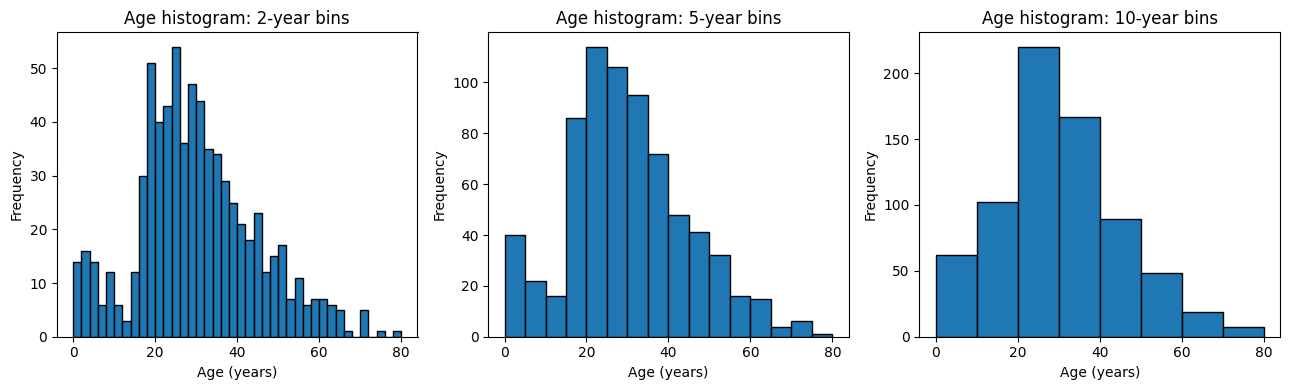

In [6]:
bin_widths = [2, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, width in zip(axes, bin_widths):
    bins = np.arange(0, age.max() + width, width)
    ax.hist(age, bins=bins, edgecolor="black")
    ax.set_title(f"Age histogram: {width}-year bins")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Choice of bin width.** I would report the **5-year bins**. The 2-year version is more jagged and emphasizes small sample fluctuations, while the 10-year version hides detail. The 5-year version balances detail and readability and still shows the main single-peaked shape with a mild right tail. Bin width matters because changing it can make the same data appear more irregular or more smooth than they really are.


## 5. Boxplot, 1.5 x IQR fences, and outliers for Age

In [7]:
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.3f}")
print(f"Q3 = {Q3:.3f}")
print(f"IQR = {IQR:.3f}")
print(f"Lower fence = {lower_fence:.3f}")
print(f"Upper fence = {upper_fence:.3f}")

age_outlier_rows = df.loc[
    age.index[(age < lower_fence) | (age > upper_fence)],
    ["PassengerId", "Name", "Age", "Sex", "Pclass"]
]
age_outlier_rows


Q1 = 20.125
Q3 = 38.000
IQR = 17.875
Lower fence = -6.688
Upper fence = 64.812


,PassengerId,Name,Age,Sex,Pclass
33,34,"Wheadon, Mr. Edward H",66.0,male,2
54,55,"Ostby, Mr. Engelhart Cornelius",65.0,male,1
96,97,"Goldschmidt, Mr. George B",71.0,male,1
116,117,"Connors, Mr. Patrick",70.5,male,3
280,281,"Duane, Mr. Frank",65.0,male,3
456,457,"Millet, Mr. Francis Davis",65.0,male,1
493,494,"Artagaveytia, Mr. Ramon",71.0,male,1
630,631,"Barkworth, Mr. Algernon Henry Wilson",80.0,male,1
672,673,"Mitchell, Mr. Henry Michael",70.0,male,2
745,746,"Crosby, Capt. Edward Gifford",70.0,male,1


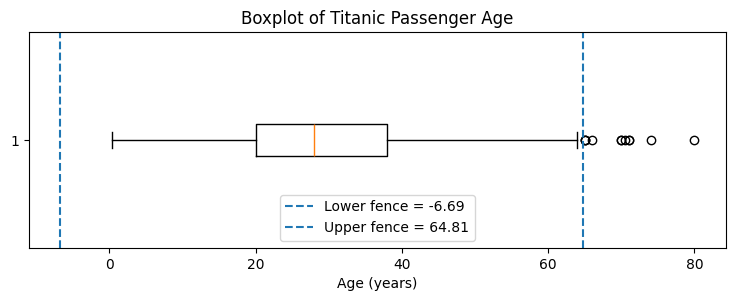

In [8]:
plt.figure(figsize=(9, 2.8))
plt.boxplot(age, vert=False, whis=1.5)
plt.axvline(lower_fence, linestyle="--", label=f"Lower fence = {lower_fence:.2f}")
plt.axvline(upper_fence, linestyle="--", label=f"Upper fence = {upper_fence:.2f}")
plt.xlabel("Age (years)")
plt.title("Boxplot of Titanic Passenger Age")
plt.legend()
plt.show()


**Outlier classification.** The Age outliers are passengers aged 65 to 80. These are **likely legitimate extreme observations**, not obvious recording errors, because the ages are humanly plausible and there is no impossible or malformed value. They should therefore be retained unless the original records provide evidence of an entry error.


## 6. Z-scores and the 68 / 95 / 99.7 comparison for Age

In [9]:
# Use the population SD for the z-score transformation.
age_mean = age.mean()
age_pop_sd = age.std(ddof=0)
age_z = (age - age_mean) / age_pop_sd

results = {}
for k in [1, 2, 3]:
    results[k] = (age_z.abs() <= k).mean() * 100

print(f"Mean Age = {age_mean:.3f}")
print(f"Population SD = {age_pop_sd:.3f}")
print()
for k, expected in zip([1, 2, 3], [68, 95, 99.7]):
    print(f"Within {k} SD: {results[k]:.1f}%   |   Normal rule: {expected}%")


Mean Age = 29.699
Population SD = 14.516

Within 1 SD: 72.3%   |   Normal rule: 68%
Within 2 SD: 95.9%   |   Normal rule: 95%
Within 3 SD: 99.7%   |   Normal rule: 99.7%


**Interpretation.** Age has approximately **72.3%** within 1 SD, **95.9%** within 2 SD, and **99.7%** within 3 SD. These are reasonably close to 68 / 95 / 99.7, so Age is approximately normal for a descriptive check, although the positive skewness of 0.389 shows a mild right tail.

**Standardisation:** converting each variable to z-scores subtracts its own mean and divides by its own standard deviation, so variables measured in different units are placed on the same unit-free scale of standard deviations from their centres.


## 7. Comparative display: Fare across passenger class (Pclass)

In [10]:
fare_by_class = df.groupby("Pclass")["Fare"].agg(["count", "mean", "median", "std"])
fare_by_class.round(2)


,count,mean,median,std
Pclass,,,,
1,216,84.15,60.29,78.38
2,184,20.66,14.25,13.42
3,491,13.68,8.05,11.78


/tmp/ipykernel_1541/3852659647.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fare_groups, labels=["1st class", "2nd class", "3rd class"], showfliers=True)


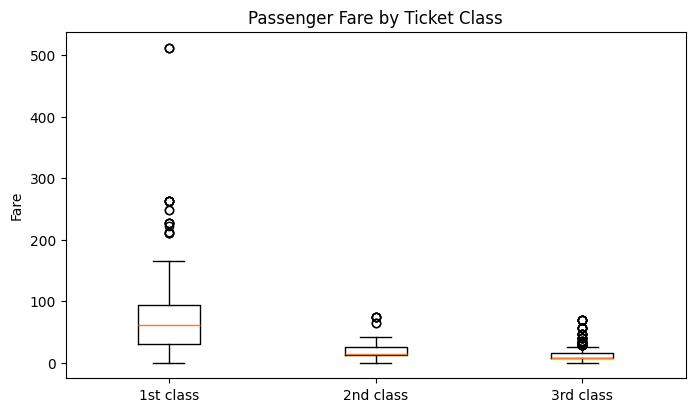

In [11]:
classes = [1, 2, 3]
fare_groups = [df.loc[df["Pclass"] == c, "Fare"].dropna() for c in classes]

plt.figure(figsize=(8, 4.5))
plt.boxplot(fare_groups, labels=["1st class", "2nd class", "3rd class"], showfliers=True)
plt.ylabel("Fare")
plt.title("Passenger Fare by Ticket Class")
plt.show()


**Comparison.** Fare differs sharply by passenger class. The median fare is about **60.29** in 1st class, **14.25** in 2nd class, and **8.05** in 3rd class. First-class fares also have a much wider spread and more high-end values. This pattern is consistent with Pclass representing different accommodation and ticket-price levels.


## 8. Final summary

- **Age** is centred near 28-30 years, is mildly right-skewed, and has moderate spread. Its z-score percentages are close to the empirical 68 / 95 / 99.7 rule, so it is approximately normal for descriptive purposes.
- **Fare** is centred much lower by the median than by the mean and is strongly right-skewed, with a much larger standard deviation caused by a long upper tail.
- The 10-row hand calculation reproduces pandas `.std()` when the sample formula divides by `n - 1`.
- Age values above the 1.5 x IQR upper fence are plausible older passengers and are best treated as legitimate extremes rather than automatically deleted.
- Fare differs substantially across the three passenger classes.
